In [51]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, ConfusionMatrixDisplay

matches = pd.read_csv('../data/processed/features_v5.csv')

# Make sure data is chronological
matches['MatchDateTime'] = pd.to_datetime(matches['MatchDateTime'])
matches = matches.sort_values('MatchDateTime').reset_index(drop=True)

In [52]:
features = [
    "EloDiff",
    "ShotOTDiffLast5",
    "GoalAgainstDiffLast5"
]

In [53]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [54]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [55]:
 
model = LogisticRegression(
    max_iter=1000,
)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [56]:
preds = model.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.4921052631578947


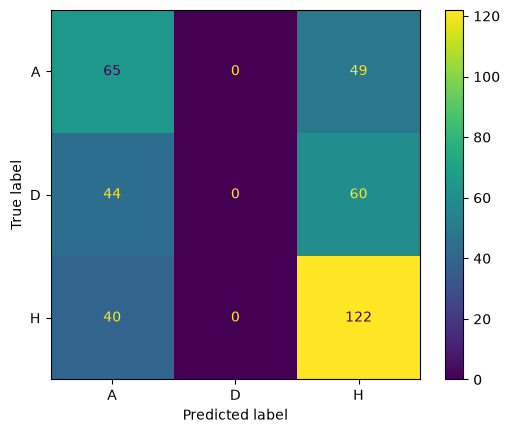

In [58]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [59]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.11259889 0.21757832 0.66982279]


In [60]:
importance = pd.DataFrame(
    model.coef_,
    columns=features,
    index=model.classes_
)

print(importance)

    EloDiff  ShotOTDiffLast5  GoalAgainstDiffLast5
A -0.003973        -0.044307             -0.071240
D  0.000595        -0.038053             -0.048897
H  0.003378         0.082360              0.120137


In [61]:
print(log_loss(y_test, probs))

1.035229549275086


In [62]:
results = test[
    ["Season", "HomeTeam", "AwayTeam", "FTR"]
].copy()

results["Predicted"] = preds
results["AwayProb"] = probs[:, 0]
results["DrawProb"] = probs[:, 1]
results["HomeProb"] = probs[:, 2]

results[60:80]

,Season,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1580,25-26,Bournemouth,Fulham,H,H,0.233352,0.222287,0.544360
1581,25-26,Leeds,Tottenham,A,A,0.431850,0.254733,0.313417
1582,25-26,Arsenal,West Ham,H,H,0.060271,0.167136,0.772594
1583,25-26,Man United,Sunderland,H,H,0.322155,0.245552,0.432293
1584,25-26,Chelsea,Liverpool,H,A,0.482579,0.226825,0.290596
1585,25-26,Wolves,Brighton,D,A,0.520502,0.229602,0.249895
1586,25-26,Newcastle,Nott'm Forest,H,H,0.214627,0.249984,0.535388
1587,25-26,Aston Villa,Burnley,H,H,0.081954,0.189917,0.728129
1588,25-26,Everton,Crystal Palace,H,A,0.426330,0.263210,0.310461
1589,25-26,Brentford,Man City,A,A,0.563317,0.220451,0.216232


In [63]:
results = test[
    ["Season", "HomeTeam", "AwayTeam", "FTR"]
].copy()

results["Predicted"] = preds

results["AwayProb"] = probs[:, 0]
results["DrawProb"] = probs[:, 1]
results["HomeProb"] = probs[:, 2]

# Maximum probability = model confidence
results["Confidence"] = probs.max(axis=1)

# -----------------------------
# Accuracy by confidence
# -----------------------------

bins = [0, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00]

labels = [
    "<40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80%+"
]

results["ConfidenceBand"] = pd.cut(
    results["Confidence"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

confidence_results = (
    results
    .groupby("ConfidenceBand", observed=True)
    .agg(
        Games=("FTR", "size"),
        Accuracy=("Predicted", lambda x:
                   (x == results.loc[x.index, "FTR"]).mean()),
        AverageConfidence=("Confidence", "mean")
    )
)

print("\nAccuracy by confidence:")
print(confidence_results)

# -----------------------------
# Accuracy by predicted result
# -----------------------------

prediction_results = (
    results
    .groupby("Predicted")
    .agg(
        Games=("FTR", "size"),
        Accuracy=("Predicted", lambda x:
                   (x == results.loc[x.index, "FTR"]).mean()),
        ActualHome=("FTR", lambda x: (x == "H").sum()),
        ActualDraw=("FTR", lambda x: (x == "D").sum()),
        ActualAway=("FTR", lambda x: (x == "A").sum())
    )
)

print("\nAccuracy by predicted result:")
print(prediction_results)

# -----------------------------
# Actual result distribution
# -----------------------------

print("\nActual result distribution:")
print(y_test.value_counts(normalize=True))

# -----------------------------
# Predicted result distribution
# -----------------------------

print("\nPredicted result distribution:")
print(pd.Series(preds).value_counts(normalize=True))

# -----------------------------
# Highest confidence predictions
# -----------------------------

print("\nHighest confidence predictions:")

print(
    results[
        [
            "HomeTeam",
            "AwayTeam",
            "FTR",
            "Predicted",
            "AwayProb",
            "DrawProb",
            "HomeProb",
            "Confidence"
        ]
    ]
    .sort_values("Confidence", ascending=False)
    .head(20)
)


Accuracy by confidence:
                Games  Accuracy  AverageConfidence
ConfidenceBand                                    
<40%               38  0.500000           0.383858
40-50%            106  0.415094           0.446673
50-60%            106  0.433962           0.543303
60-70%             83  0.578313           0.648921
70-80%             36  0.583333           0.736946
80%+               11  0.818182           0.831186

Accuracy by predicted result:
           Games  Accuracy  ActualHome  ActualDraw  ActualAway
Predicted                                                     
A            149  0.436242          40          44          65
H            231  0.528139         122          60          49

Actual result distribution:
FTR
H    0.426316
A    0.300000
D    0.273684
Name: proportion, dtype: float64

Predicted result distribution:
H    0.607895
A    0.392105
Name: proportion, dtype: float64

Highest confidence predictions:
         HomeTeam        AwayTeam FTR Predicted  A

In [64]:
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    brier_score_loss
)

# Overall metrics
print("Accuracy:", accuracy_score(y_test, preds))
print("Log Loss:", log_loss(y_test, probs))

# Brier score for each class
for i, cls in enumerate(model.classes_):
    actual = (y_test == cls).astype(int)

    score = brier_score_loss(
        actual,
        probs[:, i]
    )

    print(f"{cls} Brier Score: {score:.4f}")

Accuracy: 0.4921052631578947
Log Loss: 1.035229549275086
A Brier Score: 0.1966
D Brier Score: 0.2028
H Brier Score: 0.2249
